# OLS DID
- OLS,WLSなどのサンプル
- ここではcontrol/test*before/afterでのDIDをやる

In [ ]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
# from prophet import Prophet
# import pymc as pm
# import arviz as az

import sklearn

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
# import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

print("scikit-learn", sklearn.__version__)

Created(JST) 2026-03-20 13:27:02
pandas 2.2.0
numpy 1.26.4
matplotlib 3.10.5
seaborn 0.13.2


In [2]:
# サンプルのdataframeを生成する

import string

# 乱数の固定
np.random.seed(42)

# --- 基本設定 ---
n_customers_per_store = 100  # 1店舗あたりの顧客数
days = 14  # シミュレーション日数2週間分（前半7日が事前、後半7日が事後）
date_range = pd.date_range('2025-07-12', periods=days)
intervention_date = date_range[7]

stores = ['Store_A', 'Store_B']
# カテゴリ分け：Drink (Coffee, Tea) / Food (Cake, Sandwich)
drinks = ['Coffee', 'Tea']
foods = ['Cake', 'Sandwich']
menu = drinks + foods
base_prices = {'Coffee': 450, 'Tea': 500, 'Cake': 800, 'Sandwich': 950}

# 1. 【マスター作成】店舗ごとの顧客属性
# それぞれの顧客はA,Bいずれかの店舗にだけ来店する前提になってる
customer_data = []
for store in stores:
    chars = string.ascii_lowercase + string.digits
    ids = [''.join(np.random.choice(list(chars), 8)) for _ in range(n_customers_per_store)]
    for c_id in ids:
        customer_data.append({
            'customer_id': c_id,
            'store_id': store,
            'is_treatment': 1 if store == 'Store_A' else 0,
            'age': int(np.clip(np.random.normal(35, 10), 18, 70)),
            'gender': np.random.choice(['Male', 'Female', 'Other'])
        })

customer_master = pd.DataFrame(customer_data)

# 2. 【履歴作成】来店ログの生成
log_data = []
# 各顧客が各日に一定の確率で来店すると仮定
for _, row in customer_master.iterrows():
    is_treat_store = (row['is_treatment'] == 1)
    
    for d in date_range:
        is_post = (d >= intervention_date)
        
        # --- 1. 来店確率の変化 ---
        # 基本の来店率は40% (0.4)
        visit_prob = 0.4
        # 介入後のStore A（トリートメント群）だけ来店率を15%アップさせる
        if is_treat_store and is_post:
            visit_prob += 0.15
            
        if np.random.rand() <= visit_prob:
            # 来店した場合の注文処理
            purchased_items = []
            
            # まずは飲み物を1つ選ぶ（ベース）
            main_drink = np.random.choice(drinks)
            purchased_items.append(main_drink)
            
            # --- 2. セット注文（フード注文）の確率変化 ---
            # 通常、フードを一緒に頼む確率は25%とする
            food_prob = 0.25
            # 介入後のStore Aだけ、フード注文（セット）率を15%アップさせる
            if is_treat_store and is_post:
                food_prob += 0.15
                
            if np.random.rand() <= food_prob:
                side_food = np.random.choice(foods)
                purchased_items.append(side_food)
            
            # ログに格納
            for item in purchased_items:
                # 基本価格 + ノイズ（標準偏差20）円で価格を設定もいいが端数が出てしまう
                # price = base_prices[item] + np.random.normal(0, 20)

                # 20円刻みで変動させる
                fluctuations = [-40, -20, 0, 20, 40]  # リストからランダムに1つ選んで加算する
                probs = [0.1, 0.2, 0.4, 0.2, 0.1]  # ただし0円になる確率を高く設定（合計が1になるように調整）
                price_fluctuation = np.random.choice(fluctuations, p=probs)
                price = base_prices[item] + price_fluctuation
                log_data.append({
                    'customer_id': row['customer_id'],
                    'date': d,
                    'menu': item,
                    'price': round(price),
                    # 'is_post': 1 if is_post else 0
                })

df_log = pd.DataFrame(log_data)

# 3. 【結合と整理】
df1 = pd.merge(df_log, customer_master, on='customer_id', how='left')
# DID用の交差項を作成
# df1['interaction'] = df1['is_treatment'] * df1['is_post']

# 曜日の追加とカテゴリ変数の並び順指定
df1['weekday'] = df1['date'].dt.strftime('%a')  # 日付から自動で曜日を生成
weekdays_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df1['weekday'] = pd.Categorical(df1['weekday'], categories=weekdays_order, ordered=True)
df1['menu'] = pd.Categorical(df1['menu'], categories=menu, ordered=True)
df1['is_food'] = df1['menu'].isin(foods).astype(int)  # フードかどうかのフラグ

# 日付(date)を昇順にして、同じ日の場合は店舗(store_id)で並べる
df1 = df1.sort_values(by=['date', 'store_id']).reset_index(drop=True)

In [3]:
print(df1.head())
print(df1.tail())
# print(df1.info())

  customer_id       date    menu  price store_id  is_treatment  age  gender  \
0    x9xcvbx3 2025-07-12  Coffee    450  Store_A             1   33    Male   
1    pocguird 2025-07-12     Tea    500  Store_A             1   30  Female   
2    d2rz7j9n 2025-07-12  Coffee    410  Store_A             1   42    Male   
3    xzy2oayg 2025-07-12     Tea    520  Store_A             1   52   Other   
4    886e1gih 2025-07-12  Coffee    450  Store_A             1   37    Male   

  weekday  is_food  
0     Sat        0  
1     Sat        0  
2     Sat        0  
3     Sat        0  
4     Sat        0  
     customer_id       date      menu  price store_id  is_treatment  age  \
1622    s9j6e876 2025-07-25      Cake    840  Store_B             0   36   
1623    kjinmyb8 2025-07-25       Tea    500  Store_B             0   25   
1624    kjinmyb8 2025-07-25      Cake    800  Store_B             0   25   
1625    z5969cih 2025-07-25    Coffee    430  Store_B             0   18   
1626    z5969cih 20

In [4]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1627 entries, 0 to 1626
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   1627 non-null   object        
 1   date          1627 non-null   datetime64[ns]
 2   menu          1627 non-null   category      
 3   price         1627 non-null   int64         
 4   store_id      1627 non-null   object        
 5   is_treatment  1627 non-null   int64         
 6   age           1627 non-null   int64         
 7   gender        1627 non-null   object        
 8   weekday       1627 non-null   category      
 9   is_food       1627 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(4), object(3)
memory usage: 105.5+ KB
None


## pre process
- あとで使いそうなデータを継ぎ足すなど
- 実際にはこの工程はもっと後かもだがここでまとめてやっておくことで楽する

In [5]:
# 介入日
# base_date = df1["date"].min() + pd.Timedelta(days=7)
base_date = intervention_date
base_date

Timestamp('2025-07-19 00:00:00')

In [6]:
# 時点カラムを整数値で表現したカラムを2種用意する（後で使う）
# データセット抽出時に準備済の場合はこの工程不要
# 1つめデータセット内の最古時点を1始まりとした（絶対的な）数値カラムを新設

# df1['absolute_ds'] = df1['date'].rank(method='dense').astype(int)  # 途中欠損日があるとそこ無視した連続数値になる
df1['absolute_ds'] = (df1['date'] - df1['date'].min()).dt.days + 1  # 途中欠損日があってもなんなく連続数値になる

# 2つめ介入開始時点の1時点前を基準とした（相対的な）数値カラムを新設
# 時点がすべて連続しているデータセットの場合は、基準時点からの相対的な時点番号を取得ですむが（日次での例）
# baseline_point = pd. Timestamp(' 2024-04-21°)
df1['relative_ds'] = (df1['date'] - base_date).dt.days + 1

# 連続していない場合（control/testと同じdateで2レコードあるなど）absolute_dsから加工する
# df1['relative_ds'] = df1['absolute_ds'] - 7  # before期間が7日間で基準点が7とわかってるのでその分だけ引く

In [7]:
# 意図した通りにナンバリングできてるかcheck
# pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], values='customer_id', aggfunc='count')
pd.pivot_table(df1, index=['date', 'absolute_ds', 'relative_ds'], columns='store_id', values='customer_id', aggfunc='count')

,,store_id,Store_A,Store_B
date,absolute_ds,relative_ds,,
2025-07-12,1,-6,58,40
2025-07-13,2,-5,45,50
2025-07-14,3,-4,50,52
2025-07-15,4,-3,46,64
2025-07-16,5,-2,46,52
2025-07-17,6,-1,45,58
2025-07-18,7,0,49,45
2025-07-19,8,1,62,60
2025-07-20,9,2,75,49


In [8]:
# 後で使うカラムを3種用意する
# データセット抽出時に準備済の場合はこの工程不要

# 1つめ 階層を識別するclusterカラムを新設
# df1['cluster'] = df1['menu']
# df1['cluster'] = df1['hoge'].astype(str) + '_' + df1['hoge2'].astype(str)  # 階層が複数ある場合はこう
# df1 = df1.assign(cluster='cafe')  # 階層が1つだけの場合はこう

# 2つめ PTAの対象となる2群を識別するis_treatmentカラムを新設
# df1['is_treatment'] = np.where(df1['store_id'] == "store_A", 1, 0)

# 3つめ before/afterの識別カラムを新設
# df1['is_after'] = df1['date'].apply(lambda x: 1 if x >= pd.to_datetime('2024-05-13') else 0)  # 大量データ時にちょい時間かかる
# df1['is_after'] = df1['relative_ds'].apply(lambda x: 1 if x > 0 else 0)  # こっちのが速い

In [9]:
# pre/post区分やOLS用に0/1フラグ（is_afterカラム）を付与する

# 日付指定で振り分ける
# base_date = pd.to_datetime("2023-10-01")
df1["is_after"] = df1["date"].apply(lambda x: 1 if x >= base_date else 0)

# # is_afterをdfの末尾7daysにしたければ
# base_date = df1["date"].max() - pd.Timedelta(days=6)
# df1["is_after"] = df1["date"].apply(lambda x: 1 if x >= base_date else 0)

## 土日祝日フラグ

In [10]:
# 土日祝日フラグを追加する

# 1. 祝日データの作成
import jpholiday

# df['ds'] から期間の開始日と終了日を取得
start = df1['date'].min()
end = df1['date'].max()
# または手打ち
# start = pd.to_datetime("2025-07-01")
# end = pd.to_datetime("2025-07-31")

# 年をまたぐ可能性考えて、ユニークな年を取得
years = df1['date'].dt.year.unique()

holidays_list = []
for y in years:
    for date, name in jpholiday.year_holidays(int(y)):
        # データの期間内に入っている祝日だけ追加
        if start.date() <= date <= end.date():
            holidays_list.append({'ds': pd.to_datetime(date), 'holiday': name})

holidays_df = pd.DataFrame(holidays_list)
holidays_df

,ds,holiday
0,2025-07-21,海の日


In [11]:
# 2. 土日フラグを立てておいて（5:土曜日, 6:日曜日）
df1["is_holiday"] = df1["date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 3. holidays_df に含まれる日付（平日祝日）を 1 に更新する
# dt.normalize() を使うと時刻が 00:00:00 に揃うので比較が確実
holiday_dates = holidays_df['ds'].dt.normalize()
df1.loc[df1['date'].dt.normalize().isin(holiday_dates), "is_holiday"] = 1

In [12]:
# # 数値を文字列に変換し、1桁の場合はゼロで埋める
# df['absolute_ds_str'] = df['absolute_ds'].astype(str).str.zfill(2)
# # 時点に関するダミー変数を作成
# abs_ds_dummies = pd.get_dummies(df["absolute_ds_str"], prefix="abs_ds", drop_first=False, dtype=int)
# df_reg = pd.concat([df, abs_ds_dummies], axis=1)

In [13]:
df1.head()

,customer_id,date,menu,price,store_id,is_treatment,age,gender,weekday,is_food,absolute_ds,relative_ds,is_after,is_holiday
0,x9xcvbx3,2025-07-12,Coffee,450,Store_A,1,33,Male,Sat,0,1,-6,0,1
1,pocguird,2025-07-12,Tea,500,Store_A,1,30,Female,Sat,0,1,-6,0,1
2,d2rz7j9n,2025-07-12,Coffee,410,Store_A,1,42,Male,Sat,0,1,-6,0,1
3,xzy2oayg,2025-07-12,Tea,520,Store_A,1,52,Other,Sat,0,1,-6,0,1
4,886e1gih,2025-07-12,Coffee,450,Store_A,1,37,Male,Sat,0,1,-6,0,1


# data check

In [14]:
# 列ごとに欠損値がいくつあるか
print(df1.isnull().sum())

# 欠損値の割合で見たい場合
print(df1.isnull().mean() * 100)

customer_id     0
date            0
menu            0
price           0
store_id        0
is_treatment    0
age             0
gender          0
weekday         0
is_food         0
absolute_ds     0
relative_ds     0
is_after        0
is_holiday      0
dtype: int64
customer_id     0.0
date            0.0
menu            0.0
price           0.0
store_id        0.0
is_treatment    0.0
age             0.0
gender          0.0
weekday         0.0
is_food         0.0
absolute_ds     0.0
relative_ds     0.0
is_after        0.0
is_holiday      0.0
dtype: float64


In [15]:
# 数値データのみを対象にする
print(df1.describe())

                                date        price  is_treatment          age  \
count                           1627  1627.000000   1627.000000  1627.000000   
mean   2025-07-19 00:13:16.558082304   566.441303      0.547634    34.464044   
min              2025-07-12 00:00:00   410.000000      0.000000    18.000000   
25%              2025-07-16 00:00:00   460.000000      0.000000    27.000000   
50%              2025-07-19 00:00:00   490.000000      1.000000    34.000000   
75%              2025-07-22 00:00:00   540.000000      1.000000    40.000000   
max              2025-07-25 00:00:00   990.000000      1.000000    60.000000   
std                              NaN   173.250338      0.497879     9.769693   

           is_food  absolute_ds  relative_ds     is_after   is_holiday  
count  1627.000000  1627.000000  1627.000000  1627.000000  1627.000000  
mean      0.230486     8.009219     1.009219     0.569760     0.361401  
min       0.000000     1.000000    -6.000000     0.000000   

In [16]:
# データの期間を確認
df1['date'].max() - df1['date'].min() + pd.Timedelta(days=1)

Timedelta('14 days 00:00:00')

In [17]:
# 「数値以外（カテゴリデータなど）」の要約（頻度やユニーク数）も見たい場合
df1.describe(exclude='number')
# 期間14daysのわりに顧客のfreq17ということは、1人1日あたり複数行っぽい（単にデータが整備されてないだけの可能性もある）

,customer_id,date,menu,store_id,gender,weekday
count,1627,1627,1627,1627,1627,1627
unique,200,NaN,4,2,3,7
top,iamda571,NaN,Tea,Store_A,Male,Mon
freq,17,NaN,632,891,590,251
mean,NaN,2025-07-19 00:13:16.558082304,NaN,NaN,NaN,NaN
min,NaN,2025-07-12 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,2025-07-16 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,2025-07-19 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,2025-07-22 00:00:00,NaN,NaN,NaN,NaN
max,NaN,2025-07-25 00:00:00,NaN,NaN,NaN,NaN


In [18]:
# 特定の列（例：menu）のユニークな値
print(df1['menu'].unique())

# それぞれの出現回数（多い順に）
print(df1['menu'].value_counts())

# menu種別がわかる

['Coffee', 'Tea', 'Cake', 'Sandwich']
Categories (4, object): ['Coffee' < 'Tea' < 'Cake' < 'Sandwich']
menu
Tea         632
Coffee      620
Cake        197
Sandwich    178
Name: count, dtype: int64


In [19]:
# 特定の列のユニークな値
print(df1['gender'].unique())

# それぞれの出現回数（多い順に）
print(df1['gender'].value_counts())

['Male' 'Female' 'Other']
gender
Male      590
Other     544
Female    493
Name: count, dtype: int64


In [20]:
df1.groupby(['is_treatment', 'store_id'], observed=True)['date'].nunique()
# 介入群と統制群それぞれの店舗数は1こずつとわかる

is_treatment  store_id
0             Store_B     14
1             Store_A     14
Name: date, dtype: int64

In [21]:
df1.groupby(['is_treatment', 'store_id', 'weekday'], observed=True)['price'].describe().sort_index(level=['is_treatment', 'store_id'], ascending=[False, True]).round(1)

count   mean    std    min    25%    50%  \
is_treatment store_id weekday                                             
1            Store_A  Mon      142.0  566.3  167.6  410.0  450.0  490.0   
                      Tue      118.0  564.7  166.8  410.0  470.0  500.0   
                      Wed      133.0  567.1  172.8  410.0  450.0  480.0   
                      Thu      127.0  562.8  170.3  410.0  450.0  480.0   
                      Fri      131.0  576.1  182.5  410.0  450.0  490.0   
                      Sat      120.0  559.8  172.2  410.0  450.0  490.0   
                      Sun      120.0  576.2  187.7  410.0  460.0  490.0   
0            Store_B  Mon      109.0  548.3  167.6  410.0  450.0  480.0   
                      Tue      128.0  584.0  185.2  410.0  470.0  500.0   
                      Wed       89.0  574.8  183.1  410.0  460.0  500.0   
                      Thu      119.0  567.7  161.5  410.0  470.0  500.0   
                      Fri       92.0  565.8  170.7  410.0  460.0  500.0   
                      Sat      100.0  568.7  179.8  410.0  460.0  500.0   
                      Sun       99.0  542.6  159.5  410.0  450.0  480.0   

                                 75%    max  
is_treatment store_id weekday                
1            Store_A  Mon      705.0  990.0  
                      Tue      540.0  990.0  
                      Wed      780.0  950.0  
                      Thu      530.0  990.0  
                      Fri      650.0  990.0  
                      Sat      525.0  990.0  
                      Sun      540.0  990.0  
0            Store_B  Mon      520.0  990.0  
                      Tue      760.0  990.0  
                      Wed      540.0  990.0  
                      Thu      540.0  970.0  
                      Fri      540.0  990.0  
                      Sat      540.0  990.0  
                      Sun      520.0  990.0

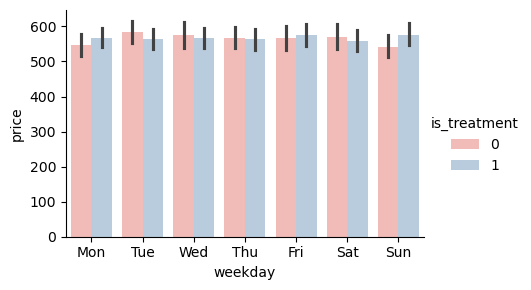

In [22]:
sns.catplot(data=df1, x="weekday", y="price", hue="is_treatment", palette="Pastel1", kind="bar", aspect=1.5, height=3)
plt.show()
# 曜日特性はあまりなさそう

## さらに詳しく

In [23]:
# 特定の列のユニークな値の数
print(df1['customer_id'].nunique())

# それぞれの出現回数（多い順に）
print(df1['customer_id'].value_counts())

# describeでunique200やfreq17だったことはわかってて、加えて、みんな出現回数が2以上と判明
# でもこの2は、1人1日あたり複数行という意味かもだし、1人が期間中に複数日来店しているのかもしれない

200
customer_id
iamda571    17
886e1gih    16
mcfh0i6x    15
nogihw2r    14
iqikox83    14
            ..
pv1t6j56     3
l0hyd6as     3
ynizbt1g     3
poy9kodu     3
70m6fxsp     2
Name: count, Length: 200, dtype: int64


In [24]:
# 顧客ごとに「来店した日付の数」を数える
visit_days = df1.groupby('customer_id')['date'].nunique()
visit_days.value_counts().sort_index()
# 期間中に1日だけ来店者もいるが1人だけ。ということは1人1日あたり複数行のデータセットっぽい目処が立つ

date
1      1
2      4
3      9
4     24
5     26
6     46
7     39
8     31
9     11
10     7
12     2
Name: count, dtype: int64

In [25]:
# ここまでの出力結果からすると、どうやらdate*custome_id単位のレコード（客単価）状態ではなさそうなので
# 同じ人が同じ日に何行データを持っているかを数える
duplicate_check = df1.groupby(['customer_id', 'date'], observed=True).size()

# そのmaxと、複数行数の件数そして占める割合を見てみる
print(duplicate_check.max())
print((duplicate_check > 1).sum())
print((duplicate_check > 1).mean())

# 1人1日で複数行のレコードもあることが改めて確認できた

2
375
0.2995207667731629


In [26]:
# では何単位で複数行になるか。登場するカラム名からするとmenuが目につく
# そこで同じ人が同じ日に同じmenuで何行データを持っているかを数える
duplicate_check2 = df1.groupby(['customer_id', 'date', 'menu'], observed=True).size()

# そのmaxと、複数行数の件数そして占める割合を見てみる
print(duplicate_check2.max())
print((duplicate_check2 > 1).sum())
print((duplicate_check2 > 1).mean())

# 1人1日1注文（menu）単位でのデータセットらしいことが判明

1
0
0.0


In [27]:
# 1人1日あたりの「ユニークなmenu数」を出す
menu_variety = df1.groupby(['customer_id', 'date'], observed=True)['menu'].count()

print(menu_variety.value_counts())  # それぞれの出現回数（多い順に）
print(menu_variety.describe())

menu
1    877
2    375
Name: count, dtype: int64
count    1252.000000
mean        1.299521
std         0.458231
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: menu, dtype: float64


## 注文単価

In [28]:
# menu（注文単価）の要約統計量
df1.groupby('menu', observed=True)['price'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
menu,,,,,,,,
Coffee,620.0,451.1,22.4,410.0,430.0,450.0,470.0,490.0
Tea,632.0,498.9,21.9,460.0,480.0,500.0,520.0,540.0
Cake,197.0,799.9,22.6,760.0,780.0,800.0,820.0,840.0
Sandwich,178.0,949.7,21.7,910.0,930.0,950.0,970.0,990.0


In [29]:
# menu（注文単価）の要約統計量
df1.groupby(['menu', 'is_treatment', 'store_id'], observed=True)['price'].describe().sort_index(level=['menu', 'is_treatment', 'store_id'], ascending=[True, False, True]).round(1)

count   mean   std    min    25%    50%  \
menu     is_treatment store_id                                            
Coffee   1            Store_A   347.0  450.6  22.9  410.0  430.0  450.0   
         0            Store_B   273.0  451.8  21.6  410.0  430.0  450.0   
Tea      1            Store_A   330.0  497.7  21.4  460.0  480.0  500.0   
         0            Store_B   302.0  500.1  22.5  460.0  480.0  500.0   
Cake     1            Store_A   119.0  798.8  22.4  760.0  780.0  800.0   
         0            Store_B    78.0  801.5  23.0  760.0  780.0  800.0   
Sandwich 1            Store_A    95.0  947.9  22.5  910.0  930.0  950.0   
         0            Store_B    83.0  951.7  20.8  910.0  930.0  950.0   

                                  75%    max  
menu     is_treatment store_id                
Coffee   1            Store_A   470.0  490.0  
         0            Store_B   470.0  490.0  
Tea      1            Store_A   520.0  540.0  
         0            Store_B   520.0  540.0  
Cake     1            Store_A   820.0  840.0  
         0            Store_B   820.0  840.0  
Sandwich 1            Store_A   970.0  990.0  
         0            Store_B   970.0  990.0

## 客数と客単価
- 1人1日単位のデータに変換して、客単価と注文点数の要約統計量を見てみる 


In [30]:
# 顧客×日付ごとに、価格は合計(sum)、メニューはリスト(list)にまとめる
# あとでも使うので必要なカラム全部入りでもいいんだが、そうするとarrayでmenuを格納しようとするからかエラーになる
df1_per_visit = df1.groupby(['customer_id', 'date', 'store_id', 'is_treatment', 'is_after']).agg({
    'price': 'sum',
    'menu': lambda x: list(x)  # ここで1つのセルにリストを格納
}).reset_index()

# リストの長さを数えて注文点数カラムを作る
df1_per_visit['item_count'] = df1_per_visit['menu'].apply(len)

df1_per_visit.head()

,customer_id,date,store_id,is_treatment,is_after,price,menu,item_count
0,007u3616,2025-07-12,Store_A,1,0,470,[Coffee],1
1,007u3616,2025-07-18,Store_A,1,0,1260,"[Tea, Cake]",2
2,007u3616,2025-07-20,Store_A,1,1,500,[Tea],1
3,007u3616,2025-07-21,Store_A,1,1,460,[Tea],1
4,007u3616,2025-07-24,Store_A,1,1,1260,"[Tea, Cake]",2


In [31]:
# 客単価の要約統計量
df1_per_visit.groupby(['is_treatment', 'store_id', 'is_after'], observed=True)['price'].describe().sort_index(level=['is_treatment', 'store_id', 'is_after'], ascending=[False, True, True]).round(1)

# 介入前後での客単価の変化だけでなく、客数の変化もなんとなく見えているか

count   mean    std    min    25%    50%  \
is_treatment store_id is_after                                             
1            Store_A  0         279.0  658.3  353.1  410.0  450.0  490.0   
                      1         398.0  809.2  426.6  410.0  470.0  500.0   
0            Store_B  0         287.0  700.5  386.0  410.0  460.0  500.0   
                      1         288.0  746.0  412.8  410.0  460.0  500.0   

                                   75%     max  
is_treatment store_id is_after                  
1            Store_A  0          540.0  1490.0  
                      1         1290.0  1530.0  
0            Store_B  0         1225.0  1510.0  
                      1         1260.0  1530.0

In [32]:
# 注文点数の要約統計量
df1_per_visit.groupby(['is_treatment', 'store_id', 'is_after'], observed=True)['item_count'].describe().sort_index(level=['is_treatment', 'store_id', 'is_after'], ascending=[False, True, True]).round(3)

# 介入前後での注文点数はあまり変わってないのかもだし、増えたのかもしれない

count   mean    std  min  25%  50%  75%  max
is_treatment store_id is_after                                              
1            Store_A  0         279.0  1.215  0.412  1.0  1.0  1.0  1.0  2.0
                      1         398.0  1.387  0.488  1.0  1.0  1.0  2.0  2.0
0            Store_B  0         287.0  1.258  0.438  1.0  1.0  1.0  2.0  2.0
                      1         288.0  1.302  0.460  1.0  1.0  1.0  2.0  2.0

# 日次単位モデル
- まずは日次単位に集約して、おおざっぱに介入効果を見てみる
- なのでここでのOLSたちは、結果変数（店舗計での総売上）に対する影響度を見てる

In [33]:
df1.columns

Index(['customer_id', 'date', 'menu', 'price', 'store_id', 'is_treatment',
       'age', 'gender', 'weekday', 'is_food', 'absolute_ds', 'relative_ds',
       'is_after', 'is_holiday'],
      dtype='object')

In [34]:
# 日次に集約したdataframeを作成
df1_daily = df1.groupby(['date', 'store_id', 'is_treatment', 'weekday', 'absolute_ds', 'relative_ds', 'is_after', 'is_holiday'], observed=True).agg(
    revenue = ('price', 'sum'),
    dau = ('customer_id', 'nunique')
    # n_orders=('customer_id', 'count')  # 注文数（延べ客数）
    ).reset_index()
# df1_daily.head()

In [35]:
# 客単価のカラムを追加
df1_daily['sales_per_visit'] = df1_daily['revenue'] / df1_daily['dau']
df1_daily.head()

,date,store_id,is_treatment,weekday,absolute_ds,relative_ds,is_after,is_holiday,revenue,dau,sales_per_visit
0,2025-07-12,Store_A,1,Sat,1,-6,0,1,32410,45,720.222222
1,2025-07-12,Store_B,0,Sat,1,-6,0,1,21990,33,666.363636
2,2025-07-13,Store_A,1,Sun,2,-5,0,1,24340,37,657.837838
3,2025-07-13,Store_B,0,Sun,2,-5,0,1,26260,43,610.697674
4,2025-07-14,Store_A,1,Mon,3,-4,0,0,26580,42,632.857143


In [36]:
# date,store_idの並びだと自己相関の考慮が想像してる感じにはならないので、store_id,dateでソートして元dfを書き換える
df1_daily.sort_values(['store_id', 'date'], inplace=True, ignore_index=True)

In [37]:
df1_daily.groupby(['is_treatment', 'store_id'])['revenue'].describe().sort_index(level=['is_treatment', 'store_id'], ascending=[False, True]).round(1)

,,count,mean,std,min,25%,50%,75%,max
is_treatment,store_id,,,,,,,,
1,Store_A,14.0,36122.9,11280.1,23360.0,25885.0,33585.0,47282.5,53830.0
0,Store_B,14.0,29705.7,5388.2,21010.0,26282.5,29205.0,34037.5,37610.0


In [38]:
# # 大きな数値を桁上げしたい
# df1["value1_million"] = df1["value1"] / (10**6)  # 百万で割る
df1_daily["revenue_thousand"] = df1_daily["revenue"] / (10**3)  # 千で割る

In [39]:
df1_daily.groupby(['is_treatment', 'store_id', 'is_after'])['revenue_thousand'].describe().sort_index(level=['is_treatment', 'store_id', 'is_after'], ascending=[False, True, True]).round(1)

count  mean  std   min   25%   50%   75%   max
is_treatment store_id is_after                                                
1            Store_A  0           7.0  26.2  3.0  23.4  24.6  25.7  26.6  32.4
                      1           7.0  46.0  6.2  34.8  43.3  48.1  49.3  53.8
0            Store_B  0           7.0  28.7  5.0  22.0  26.0  28.3  30.6  37.6
                      1           7.0  30.7  6.0  21.0  26.9  31.5  35.7  37.1

In [40]:
df1_daily.groupby(['is_treatment', 'store_id', 'is_after'])['dau'].describe().sort_index(level=['is_treatment', 'store_id', 'is_after'], ascending=[False, True, True]).round(1)

count  mean  std   min   25%   50%   75%   max
is_treatment store_id is_after                                                
1            Store_A  0           7.0  39.9  3.3  35.0  38.0  40.0  41.5  45.0
                      1           7.0  56.9  5.3  50.0  53.0  57.0  60.5  64.0
0            Store_B  0           7.0  41.0  5.6  33.0  37.0  43.0  44.5  48.0
                      1           7.0  41.1  6.7  29.0  38.5  42.0  45.5  49.0

In [41]:
df1_daily.groupby(['is_treatment', 'store_id', 'is_after'])['sales_per_visit'].describe().sort_index(level=['is_treatment', 'store_id', 'is_after'], ascending=[False, True, True]).round(1)

count   mean   std    min    25%    50%  \
is_treatment store_id is_after                                            
1            Store_A  0           7.0  658.6  52.1  584.0  634.0  647.1   
                      1           7.0  807.0  54.2  695.2  797.4  829.5   
0            Store_B  0           7.0  700.9  75.4  610.7  652.1  666.4   
                      1           7.0  744.3  64.5  685.0  699.3  724.5   

                                  75%    max  
is_treatment store_id is_after                
1            Store_A  0         689.0  733.4  
                      1         835.4  858.6  
0            Store_B  0         753.7  817.6  
                      1         766.5  869.0

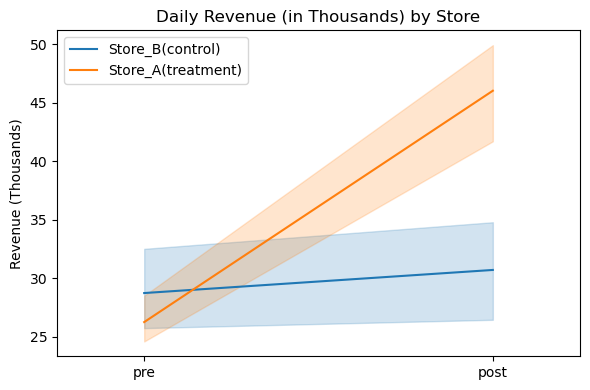

In [42]:
groups = df1_daily['is_after'].astype(str).unique().tolist()
groups = ['pre', 'post']  # 0/1のままだとグラフのx軸が見にくいので、文字列に変換しておく
x_pos = np.arange(len(groups))

plt.figure(figsize=(6, 4))
# sns.lineplot(data=df1_daily, x='is_after', y='revenue_thousand', hue='is_treatment')
sns.lineplot(x=df1_daily.query('is_treatment == 0')['is_after'], y=df1_daily.query('is_treatment == 0')['revenue_thousand'], label='Store_B(control)')
sns.lineplot(x=df1_daily.query('is_treatment == 1')['is_after'], y=df1_daily.query('is_treatment == 1')['revenue_thousand'], label='Store_A(treatment)')

plt.xlim(-0.25, len(groups) - 0.75)  # x軸の余白調整、未指定だとx軸の左右に余白がなくて見映えがよくない
plt.xticks(x_pos, groups)
plt.title('Daily Revenue (in Thousands) by Store')
plt.xlabel('')
plt.ylabel('Revenue (Thousands)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

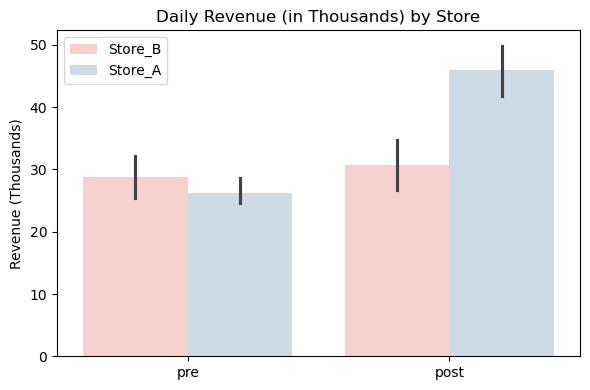

In [43]:
groups = df1_daily['is_after'].astype(str).unique().tolist()
groups = ['pre', 'post']  # 0/1のままだとグラフのx軸が見にくいので、文字列に変換しておく
x_pos = np.arange(len(groups))

plt.figure(figsize=(6, 4))
sns.barplot(data=df1_daily, x='is_after', y='revenue_thousand', hue='store_id', alpha=0.7, hue_order=['Store_B', 'Store_A'], palette='Pastel1')
plt.xticks(x_pos, groups)
plt.title('Daily Revenue (in Thousands) by Store')
plt.xlabel('')
plt.ylabel('Revenue (Thousands)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

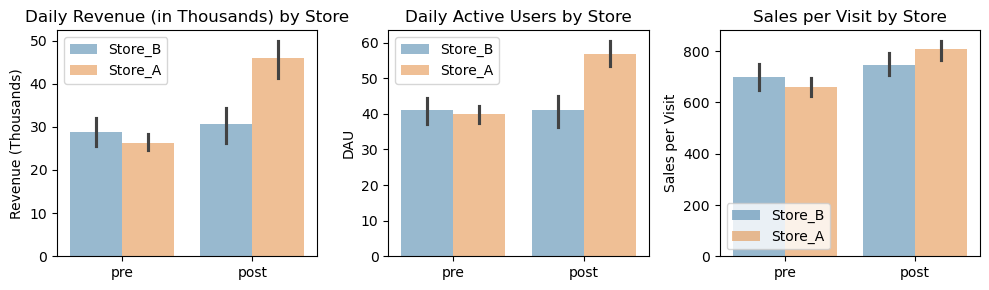

In [44]:
groups = df1_daily['is_after'].astype(str).unique().tolist()
groups = ['pre', 'post']  # 0/1のままだとグラフのx軸が見にくいので、文字列に変換しておく
x_pos = np.arange(len(groups))
hue_orders = ['Store_B', 'Store_A']  # 凡例の順番を指定
color_orders = ['tab:blue', 'tab:orange']  # 色の順番を指定


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3)) # 1行3列のグリッドでaxesを作成

# 総売上
sns.barplot(data=df1_daily, x='is_after', y='revenue_thousand', hue='store_id', alpha=0.5, hue_order=hue_orders, palette=color_orders, ax=axes[0])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(groups)
axes[0].set_title('Daily Revenue (in Thousands) by Store')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (Thousands)')
axes[0].legend(loc='best')

# 客数
sns.barplot(data=df1_daily, x='is_after', y='dau', hue='store_id', alpha=0.5, hue_order=hue_orders, palette=color_orders, ax=axes[1])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(groups)
axes[1].set_title('Daily Active Users by Store')
axes[1].set_xlabel('')
axes[1].set_ylabel('DAU')
axes[1].legend(loc='best')

# 客単価
sns.barplot(data=df1_daily, x='is_after', y='sales_per_visit', hue='store_id', alpha=0.5, hue_order=hue_orders, palette=color_orders, ax=axes[2])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(groups)
axes[2].set_title('Sales per Visit by Store')
axes[2].set_xlabel('')
axes[2].set_ylabel('Sales per Visit')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()


In [45]:
# 後続のグラフ表記に使用

# min,maxを取得
min_value = df1_daily['revenue_thousand'].min()
max_value = df1_daily['revenue_thousand'].max()

# オーダー（桁数）を取得
order_of_magnitude = int(np.floor(np.log10(max_value - min_value)))

# スケールを設定（オーダーに基づいて10の倍数に調整）
scale = 10 ** (order_of_magnitude - 1)

# min,max_limを設定
min_lim = np.floor(min_value / scale) * scale
max_lim = np.ceil(max_value / scale) * scale


# 桁数調整が不要なときは
# min_lim = min_value
# max_lim = max_value

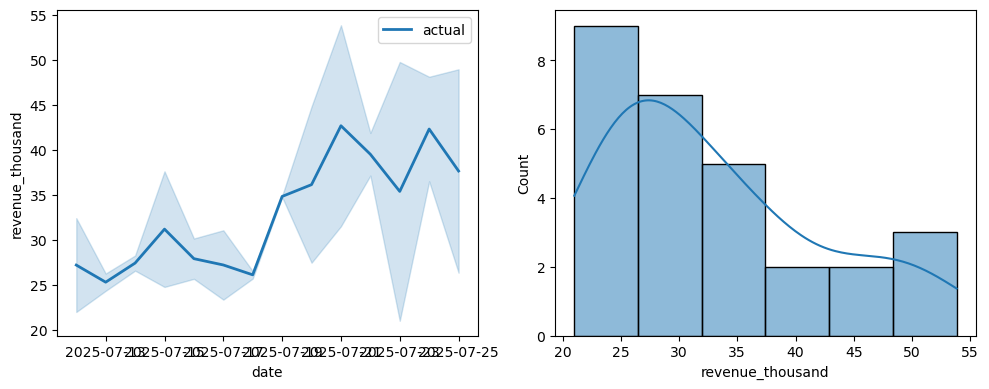

In [46]:
plt.figure(figsize=(10,4))

plt.subplot(121)  # グラフ1行2列の1番目
sns.lineplot(data=df1_daily, x='date', y='revenue_thousand', linewidth=2, label='actual')

plt.subplot(122)  # グラフ1行2列の2番目
sns.histplot(data=df1_daily, x='revenue_thousand', kde=True)

plt.tight_layout()

In [47]:
# グラフ描画用には分けておく方が楽だったりする
df1_daily_control = df1_daily.query('is_treatment==0').reset_index(drop=True).copy()
df1_daily_test = df1_daily.query('is_treatment==1').reset_index(drop=True).copy()

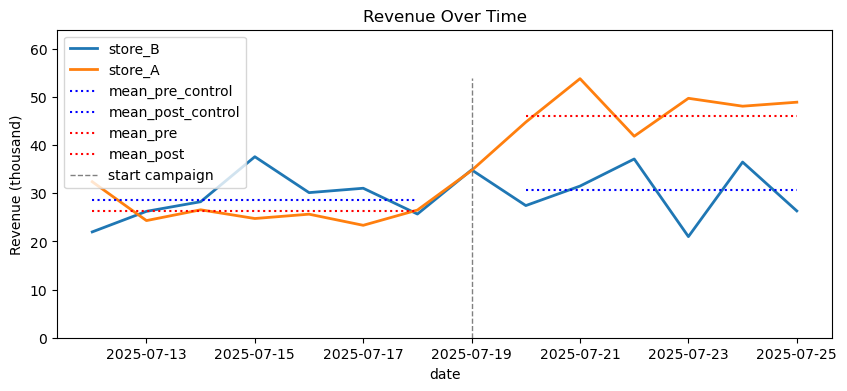

mean pre: 26.2
mean post: 46.0
diff: 19.8

mean pre control: 28.7
mean post control: 30.7
diff control: 2.0


In [48]:
# plot
plt.figure(figsize=(10,4))
sns.lineplot(data=df1_daily_control, x='date', y='revenue_thousand', linewidth=2, label='store_B')
sns.lineplot(data=df1_daily_test, x='date', y='revenue_thousand', linewidth=2, label='store_A')


# mean pre/post(control)
mean_pre_control = df1_daily_control.query('date < @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=df1_daily_control['date'].min(), xmax=base_date - pd.Timedelta(days=1), y=mean_pre_control, color="blue", linestyles="dotted", linewidth=1.5, label="mean_pre_control")

mean_post_control = df1_daily_control.query('date >= @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df1_daily_control['date'].max(), y=mean_post_control, color="blue", linestyles="dotted", linewidth=1.5, label="mean_post_control")


# mean pre/post(test)
mean_pre = df1_daily_test.query('date < @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=df1_daily_test['date'].min(), xmax=base_date - pd.Timedelta(days=1), y=mean_pre, color="red", linestyles="dotted", linewidth=1.5, label="mean_pre")

mean_post = df1_daily_test.query('date >= @base_date')['revenue_thousand'].mean()
plt.hlines(xmin=base_date + pd.Timedelta(days=1), xmax=df1_daily_test['date'].max(), y=mean_post, color="red", linestyles="dotted", linewidth=1.5, label="mean_post")


# base_date
plt.vlines(x=base_date, ymin=0, ymax=max_lim, colors="gray", linestyles="dashed", linewidth=1, label="start campaign")

# plt.ylim(min_lim, max_lim)
plt.ylim(0, max_lim+10)

plt.ylabel("Revenue (thousand)")
plt.title("Revenue Over Time")
plt.legend(loc="best")
plt.show()


print(f"mean pre: {(mean_pre).round(1)}")
print(f"mean post: {(mean_post).round(1)}")
print(f"diff: {(mean_post - mean_pre).round(1)}")
print('\n', end='')  # 空白1行を挟む
print(f"mean pre control: {(mean_pre_control).round(1)}")
print(f"mean post control: {(mean_post_control).round(1)}")
print(f"diff control: {(mean_post_control - mean_pre_control).round(1)}")
# 介入効果とも思えるし、上がり基調なトレンドとも思える

## OLS

In [49]:
# ols
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

model_ols = smf.ols(formula="revenue_thousand ~ is_treatment + is_after + is_treatment:is_after", data=df1_daily).fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       revenue_thousand   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     20.56
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           8.09e-07
Time:                        13:27:04   Log-Likelihood:                -83.752
No. Observations:                  28   AIC:                             175.5
Df Residuals:                      24   BIC:                             180.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                28.7186      1.967     14.603      0.000      24.660      32.777
is_treatment             -2.4814      2.781     -0.892      0.381      -8.222       3.259
is_after                  1.9743      2.781      0.710      0.485      -3.766       7.714
is_treatment:is_after    17.7971      3.933      4.525      0.000       9.679      25.915
==============================================================================
Omnibus:                        0.552   Durbin-Watson:                   2.555
Prob(Omnibus):                  0.759   Jarque-Bera (JB):                0.370
Skew:                          -0.269   Prob(JB):                        0.831
Kurtosis:                       2.836   Cond. No.                         6.85
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
# 後でグラフ描画にも使うのでいったん値を格納

# 結果を溜める空リスト
daily_results = []

# appendで追加していく
daily_results.append({
    'group': 'OLS',
    'note': 'non_robust',
    'coefficient': model_ols.params['is_treatment:is_after'],
    'p_value': model_ols.pvalues['is_treatment:is_after'],
    'ci_lower': model_ols.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_ols.conf_int().loc['is_treatment:is_after', 1]
})

In [51]:
print("DID Interaction Effect: Daily Revenue by Store (1,000 JPY)")
# pd.DataFrame(daily_results)
pd.DataFrame(daily_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Revenue by Store (1,000 JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9


## 残差診断
- 左上: resid_fit() 残差と予測値のプロット  
  - 横軸：yの予測値yhat  縦軸：残差 
  - （目的）残差に非線形のパターンがないかの確認。縦軸の0を中心に上下にランダムに散らばっている場合、回帰式は線形と判断できるが、上向きやU字型や何らかのパターンがあると非線形の可能性が示唆される
  - 実線は残差の散らばりに最もフィットする曲線。平行な点線が理想的。絶対値が最も大きい３つの残差にインデックスの数字が示されている。

- 右上：Q-Qプロット qはquantile（分位数）のこと  
  - 横軸：横軸に標準正規分布の理論値  縦軸：標準化残差（standardized residuals）  標準化残差とは平均0，分散1に変換した残差
  - （目的）残差が正規分布に従っているかの確認。データが正規分布に従っている場合、45度線（赤の点線）に沿って分布する。残差が概ね45度線近傍にあれば問題ない。しかし多くの残差が45度線から外れている場合は正規分布ではない可能性が大きくなる。

- 左下: scale_loc()
  - 横軸：yの予測値yhat  縦軸：標準化残差（standardized residuals）の絶対値のルート
  - （目的）残差が均一分散かどうかの確認。上下方向の散らばりが概ね均等であれば均一分散と解釈できるが，何らかのパターンがあれば不均一分散の可能性がある。
  - 実線は残差の散らばりに最もフィットする曲線。横軸に平行となるのが理想的。絶対値が最も大きい３つの残差にインデックスの数字表記。

- 右下: resid_lev()
  - 縦軸：標準化残差（standardized residuals）99.7%の確率で(-3,3)の間に入る
    - 観測値が予測値からどれだけ離れているかを示す（外れ値=outlier）。
    - 縦軸の絶対値が大きい（例えば、絶対値3以上）と外れ値の可能性が高まる。
    - この距離が長くなると（絶対値が大きくなると），推定値に大きな影響力をもつ可能性が高くなる。
  - 横軸：レバレッジ（leverage）
    - 説明変数がどれだけ「極端」な値を取るかを示す。
    - 単回帰の場合: 説明変数xiと平均のxの間の距離を示す。この距離が長くなると，推定値に影響力をもつ可能性が高くなり，高いレバレッジの値として反映される。
    - 重回帰の場合: 説明変数のうち１つ以上の説明変数の値が極端に大きい場合や小さい場合にレバレッジは高くなる。また説明変数の値の組み合わせが「通常」ではない場合にもレバレッジは高くなる。
  - （目的）OLS推定値を計算する上で影響力が大きい観測値を特定し，推定値が小数の観測値に大きく左右されていないかを確認する。そのような影響力がある観測値は図の右上と右下に現れ，特に点線（Cook’s Distanceと呼ばれる）の外（右上と右下）にある場合は要注意（右の真ん中のエリアは重要ではない）。観測値の散らばりやそのパターンは関係ない。
  - 影響力がある観測値: レバレッジと標準化残差の絶対値の両方が大きい観測値。最も影響力が大きい観測値にインデックスの数字が示されている。
  - 点線：Cook’s Distance (CD) ある観測値を外して再計算するとどれだけ予測値が変化するかを数値化したもの。内側の点線：CD = 0.5  外側の点線：CD = 1
  - 点線は観測値にフィットする曲線。点線は表示されない場合もある（CDが極端に大きいもの0.5以上がないとなのかな）

<Figure size 1000x800 with 0 Axes>

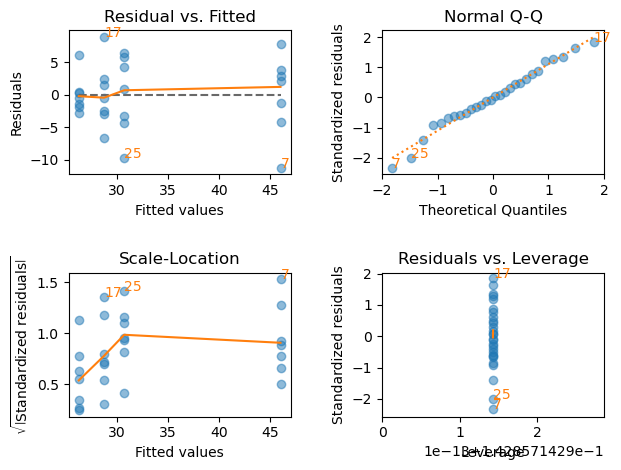

In [52]:
# まとめて
import lmdiag
plt.figure(figsize=(10, 8))
lmdiag.plot(model_ols)
pass

# 個別にやる場合
# lmdiag.resid_fit(model_ols)
# pass
# lmdiag.q_q(model_ols)
# pass
# lmdiag.scale_loc(model_ols)
# pass
# lmdiag.resid_lev(model_ols)
# pass

In [53]:
# 目立つインデックスをリストで指定
outlier_indices = [7, 14, 23]

# その行だけを抽出して表示
df1_daily.loc[outlier_indices]

,date,store_id,is_treatment,weekday,absolute_ds,relative_ds,is_after,is_holiday,revenue,dau,sales_per_visit,revenue_thousand
7,2025-07-19,Store_A,1,Sat,8,1,1,1,34760,50,695.200000,34.76
14,2025-07-12,Store_B,0,Sat,1,-6,0,1,21990,33,666.363636,21.99
23,2025-07-21,Store_B,0,Mon,10,3,1,1,31510,46,685.000000,31.51


In [54]:
# 上のをもう少し自動化したい（元のdataframe名などは書き換える必要ある）
# 残差診断のグラフは4つあるが、縦軸はいずれも残差に関連するものなので、標準化残差の絶対値が大きいもの3つを取得する
# ただし右下グラフで表示されるindexは残差だけで決まるわけでもなさそうなのでCDの大きいもの3つも取得する
# これでうまくいくかは別のデータセットでも試してみないとね

# 残差診断オブジェクトを取得
influence = model_ols.get_influence()
std_resids = np.abs(influence.resid_studentized_internal)
cooks_d = influence.cooks_distance[0]
# 標準化残差とCook's Distanceの上位3つずつのインデックスを取得
top_std = set(np.argsort(std_resids)[-3:])
top_cook = set(np.argsort(cooks_d)[-3:])
# まとめて抽出
all_targets = sorted(list(top_std | top_cook))

# 元のdataframeとっくつけて
outlier_df = df1_daily.loc[all_targets].copy()
# 理由をラベル化
outlier_df['is_outlier'] = outlier_df.index.isin(top_std)
outlier_df['is_influential'] = outlier_df.index.isin(top_cook)
outlier_df['std_resid'] = std_resids[all_targets]
outlier_df['cooks_d'] = cooks_d[all_targets]

print(outlier_df[['date', 'weekday', 'store_id', 'revenue_thousand', 'std_resid', 'cooks_d', 'is_outlier', 'is_influential']])

         date weekday store_id  revenue_thousand  std_resid   cooks_d  \
7  2025-07-19     Sat  Store_A             34.76   2.335094  0.227194   
17 2025-07-15     Tue  Store_B             37.61   1.845774  0.141953   
25 2025-07-23     Wed  Store_B             21.01   2.010067  0.168349   

    is_outlier  is_influential  
7         True            True  
17        True            True  
25        True            True  


In [55]:
# 上のをもう少し自動化したい（元のdataframe名などは書き換える必要ある）
# そしてどうせならdate別の標準化残差を描くデータセットにもしたい（これをプロットして残差の自己相関あるかを目視したい）

# 残差診断のグラフは4つあるが、縦軸はいずれも残差に関連するものなので、標準化残差の絶対値が大きいもの3つを取得する
# ただし右下グラフで表示されるindexは残差だけで決まるわけでもなさそうなのでCDの大きいもの3つも取得する
# これでうまくいくかは別のデータセットでも試してみないとね

# 1. 全レコード分の残差診断オブジェクトを取得
influence = model_ols.get_influence()
df_diag = df1_daily.copy()

# すべての行に標準化残差とCook's Distanceを付与
df_diag['std_resid'] = influence.resid_studentized_internal
df_diag['cooks_d'] = influence.cooks_distance[0]

# 2. 上位3件の閾値を特定してフラグ立て
threshold_std = np.sort(np.abs(df_diag['std_resid']))[-4] # 上位3つより大きい境界
threshold_cook = np.sort(df_diag['cooks_d'])[-4]

# True/Falseのフラグを立てる
df_diag['is_outlier'] = np.abs(df_diag['std_resid']) > threshold_std
df_diag['is_influential'] = df_diag['cooks_d'] > threshold_cook

# 3. 残差診断でindex表示されたレコードを絞り込み表示して中身確認
targets = df_diag[df_diag['is_outlier'] | df_diag['is_influential']]
targets[['date', 'weekday', 'store_id', 'revenue_thousand', 'std_resid', 'cooks_d', 'is_outlier', 'is_influential']]

,date,weekday,store_id,revenue_thousand,std_resid,cooks_d,is_outlier,is_influential
7,2025-07-19,Sat,Store_A,34.76,-2.335094,0.227194,True,True
17,2025-07-15,Tue,Store_B,37.61,1.845774,0.141953,True,True
25,2025-07-23,Wed,Store_B,21.01,-2.010067,0.168349,True,True


## 残差の自己相関
- lmdiagでは均一分散や外れ値の確認はできるが、残差の自己相関の確認はできない
- のでそこをみていく（時系列データというか残差の自己相関を心配しないでいいデータセットなら不要だろう）

In [56]:
# 1時点前との残差列を作る
df_diag['std_resid_lag1'] = df_diag.groupby('store_id')['std_resid'].shift(1)

df_diag_control = df_diag.query('is_treatment==0').reset_index(drop=True).copy()
df_diag_test = df_diag.query('is_treatment==1').reset_index(drop=True).copy()

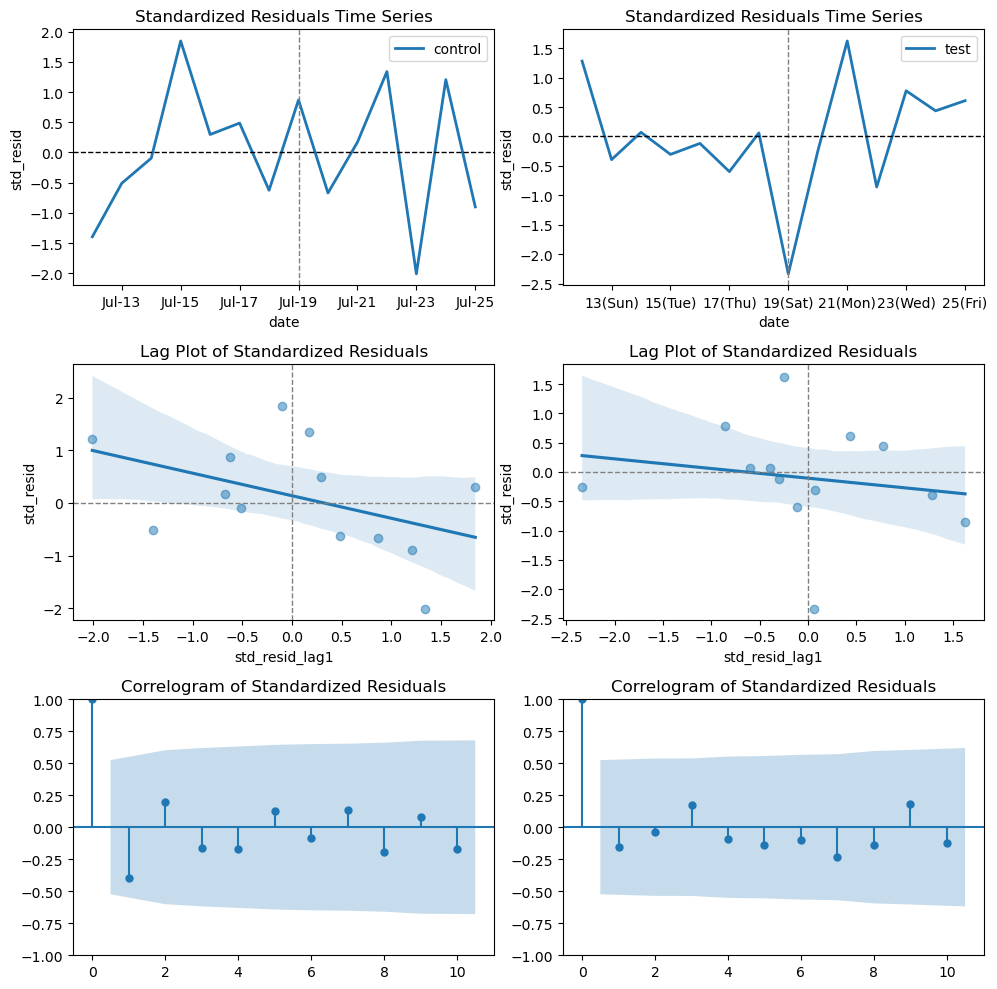

In [57]:
# 残差の自己相関いろいろ
import matplotlib.dates as mdates
from scipy.stats import norm
import statsmodels.api as sm

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10)) # 3行2列のグリッドでaxesを作成
# fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 10)) # 4行2列 ヒストグラムも見たいとき用

# 標準化残差の系列
sns.lineplot(data=df_diag_control, x='date', y='std_resid', linewidth=2, label='control', ax=axes[0, 0])
axes[0, 0].axvline(base_date, color="gray", linestyle="dashed", linewidth=1)
axes[0, 0].axhline(0, color="black", linestyle="dashed", linewidth=1)
axes[0, 0].set_ylabel("std_resid")
axes[0, 0].set_title("Standardized Residuals Time Series")
axes[0, 0].legend(loc="best")
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))

sns.lineplot(data=df_diag_test, x='date', y='std_resid', linewidth=2, label='test', ax=axes[0, 1]) 
axes[0, 1].axvline(x=base_date, color="gray", linestyle="dashed", linewidth=1)
axes[0, 1].axhline(0, color="black", linestyle="dashed", linewidth=1)
axes[0, 1].set_title("Standardized Residuals Time Series")
axes[0, 1].legend(loc="best")
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%d(%a)'))

# 標準化残差のラグの散布図
sns.regplot(data=df_diag_control, x='std_resid_lag1', y='std_resid', scatter_kws={'alpha':0.5}, ax=axes[1, 0])
axes[1, 0].axhline(0, color="gray", linestyle="dashed", linewidth=1)
axes[1, 0].axvline(0, color="gray", linestyle="dashed", linewidth=1)
axes[1, 0].set_title("Lag Plot of Standardized Residuals")

sns.regplot(data=df_diag_test, x='std_resid_lag1', y='std_resid', scatter_kws={'alpha':0.5}, ax=axes[1, 1])    
axes[1, 1].axhline(0, color="gray", linestyle="dashed", linewidth=1)
axes[1, 1].axvline(0, color="gray", linestyle="dashed", linewidth=1)
axes[1, 1].set_title("Lag Plot of Standardized Residuals")

# 標準化残差のコレログラム
sm.graphics.tsa.plot_acf(df_diag_control['std_resid'], lags=10, title="Correlogram of Standardized Residuals", ax=axes[2, 0])

sm.graphics.tsa.plot_acf(df_diag_test['std_resid'], lags=10, title="Correlogram of Standardized Residuals", ax=axes[2, 1])

# # 標準化残差のヒストグラムと正規分布
# sns.histplot(data=df_diag_control, x="std_resid", stat="density", label='hist', ax=axes[3, 0]) 
# norm_x = np.linspace(df_diag['std_resid'].min(), df_diag['std_resid'].max(), 100)
# norm_y = norm.pdf(norm_x, loc=0, scale=1)
# axes[3, 0].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
# axes[3, 0].set_title("Histogram of Standardized Residuals")
# axes[3, 0].legend(loc="best")

# sns.histplot(data=df_diag_test, x="std_resid", stat="density", label='hist', ax=axes[3, 1])
# norm_x = np.linspace(df_diag['std_resid'].min(), df_diag['std_resid'].max(), 100)
# norm_y = norm.pdf(norm_x, loc=0, scale=1)
# axes[3, 1].plot(norm_x, norm_y, color="tab:green", label="N(0,1)")
# axes[3, 1].set_title("Histogram of Standardized Residuals")
# axes[3, 1].legend(loc="best")

plt.tight_layout()
plt.show()
# 1段目グラフはジグザグ感があり、2段目グラフは右肩下がり傾向
# DWは2を超えてたことから残差には負の相関はありそうだが、3段目グラフの通りそこまででもな感じ

## OLS robust

In [58]:
# robust 頑健標準誤差(HC3)を適用して学習
model_ols_robust = smf.ols(formula="revenue_thousand ~ is_treatment + is_after + is_treatment:is_after", data=df1_daily).fit(cov_type='HC3')
model_ols_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       revenue_thousand   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     16.54
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           4.84e-06
Time:                        13:27:05   Log-Likelihood:                -83.752
No. Observations:                  28   AIC:                             175.5
Df Residuals:                      24   BIC:                             180.8
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                28.7186      2.022     14.201      0.000      24.755      32.682
is_treatment             -2.4814      2.356     -1.053      0.292      -7.100       2.137
is_after                  1.9743      3.179      0.621      0.535      -4.256       8.205
is_treatment:is_after    17.7971      4.248      4.189      0.000       9.471      26.124
==============================================================================
Omnibus:                        0.552   Durbin-Watson:                   2.555
Prob(Omnibus):                  0.759   Jarque-Bera (JB):                0.370
Skew:                          -0.269   Prob(JB):                        0.831
Kurtosis:                       2.836   Cond. No.                         6.85
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [59]:
# 後でグラフ描画にも使うのでいったん値を格納
# appendで追加していく
daily_results.append({
    'group': 'OLS',
    'note': 'HC3',
    'coefficient': model_ols_robust.params['is_treatment:is_after'],
    'p_value': model_ols_robust.pvalues['is_treatment:is_after'],
    'ci_lower': model_ols_robust.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_ols_robust.conf_int().loc['is_treatment:is_after', 1]
})

In [60]:
print("DID Interaction Effect: Daily Revenue by Store (1,000 JPY)")
# pd.DataFrame(daily_results)
pd.DataFrame(daily_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Revenue by Store (1,000 JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9
1,OLS,HC3,17.8,0.000028,9.5,26.1


## GLSAR
- 日次データだと残差の自己相関の可能性があるので、GLSARも試してみる
- このデータセットの場合は、DWが2.5と残差の自己相関の可能性はさほど高くないんだがいちおう見ておく

In [61]:
df1_daily.head()

,date,store_id,is_treatment,weekday,absolute_ds,relative_ds,is_after,is_holiday,revenue,dau,sales_per_visit,revenue_thousand
0,2025-07-12,Store_A,1,Sat,1,-6,0,1,32410,45,720.222222,32.41
1,2025-07-13,Store_A,1,Sun,2,-5,0,1,24340,37,657.837838,24.34
2,2025-07-14,Store_A,1,Mon,3,-4,0,0,26580,42,632.857143,26.58
3,2025-07-15,Store_A,1,Tue,4,-3,0,0,24770,39,635.128205,24.77
4,2025-07-16,Store_A,1,Wed,5,-2,0,0,25670,35,733.428571,25.67


In [62]:
# GLSARだと交互作用項はあらかじめ用意する必要あるので
df1_daily_glsar = df1_daily.copy()
df1_daily_glsar["interaction"] = df1_daily_glsar["is_treatment"] * df1_daily_glsar["is_after"]

X = df1_daily_glsar[["is_treatment", "is_after", "is_holiday", "interaction"]]
X = sm.add_constant(X)  # 定数項の追加
y = df1_daily_glsar["revenue_thousand"]

### rho=1

In [63]:
# GLSAR（1次自己相関）を考慮
glsar_1 = sm.GLSAR(y, X, rho=1)
model_glsar_1 = glsar_1.iterative_fit(maxiter=10)
model_glsar_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           GLSAR Regression Results                           
==============================================================================
Dep. Variable:       revenue_thousand   R-squared:                       0.861
Model:                          GLSAR   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     33.94
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           4.05e-09
Time:                        13:27:05   Log-Likelihood:                -77.427
No. Observations:                  27   AIC:                             164.9
Df Residuals:                      22   BIC:                             171.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           29.7995      1.411     21.126      0.000      26.874      32.725
is_treatment    -4.2076      1.932     -2.177      0.040      -8.215      -0.200
is_after         1.7148      1.939      0.885      0.386      -2.306       5.735
is_holiday      -2.0782      1.619     -1.284      0.212      -5.435       1.278
interaction     19.6894      2.730      7.214      0.000      14.029      25.350
==============================================================================
Omnibus:                        0.505   Durbin-Watson:                   2.157
Prob(Omnibus):                  0.777   Jarque-Bera (JB):                0.122
Skew:                          -0.164   Prob(JB):                        0.941
Kurtosis:                       3.034   Cond. No.                         7.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
# 後でグラフ描画にも使うのでいったん値を格納
# appendで追加していく
daily_results.append({
    'group': 'GLSAR',
    'note': 'rho=1',
    'coefficient': model_glsar_1.params['interaction'],
    'p_value': model_glsar_1.pvalues['interaction'],
    'ci_lower': model_glsar_1.conf_int().loc['interaction', 0],
    'ci_upper': model_glsar_1.conf_int().loc['interaction', 1]
})

In [65]:
print("DID Interaction Effect: Daily Revenue by Store (1,000 JPY)")
# pd.DataFrame(daily_results)
pd.DataFrame(daily_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Revenue by Store (1,000 JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9
1,OLS,HC3,17.8,0.000028,9.5,26.1
2,GLSAR,rho=1,19.7,0.000000,14.0,25.4


In [66]:
glsar_1.rho
# rhoは、1期前の残差と今期の残差の相関、自己相関の強さを表すパラメータで、0に近いほど自己相関が弱いことを示す。0〜1の値を取る
# 0〜0.3 弱い自己相関（ほぼ独立）
# 0.3〜0.7 中程度の自己相関
# 0.7〜0.95 強い自己相関（残差が滑らかに続く）
# ほぼ1 ほぼランダムウォーク的（強すぎ）

array([-0.37369728])

In [67]:
# # GLSARの結果の残差を使ってACFプロット
# # なんだが、control/test不問になっちゃうので、先の工程、残差の自己相関のところを参照した方がよい

# # sm.graphics.plot_acf(results_glsar_1.resid, lags=10)
# # で実行できない場合は以下
# from statsmodels.graphics.tsaplots import plot_acf
# plot_acf(model_glsar_1.resid, lags=10)
# plt.show()

## WLS

In [68]:
# dauを重みとして指定する
# 重みは「信頼度」を意味するので、客数が多いほど重みを大きくする
model_wls = smf.wls(formula="revenue_thousand ~ is_treatment + is_after + is_treatment:is_after", data=df1_daily, weights=df1_daily['dau']).fit(cov_type='HC3')
model_wls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:       revenue_thousand   R-squared:                       0.748
Model:                            WLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     17.54
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.03e-06
Time:                        13:27:05   Log-Likelihood:                -83.972
No. Observations:                  28   AIC:                             175.9
Df Residuals:                      24   BIC:                             181.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                29.1509      2.039     14.296      0.000      25.154      33.148
is_treatment             -2.7638      2.436     -1.134      0.257      -7.539       2.011
is_after                  2.2885      3.003      0.762      0.446      -3.596       8.173
is_treatment:is_after    17.7912      4.097      4.342      0.000       9.760      25.822
==============================================================================
Omnibus:                        0.656   Durbin-Watson:                   2.507
Prob(Omnibus):                  0.720   Jarque-Bera (JB):                0.215
Skew:                          -0.212   Prob(JB):                        0.898
Kurtosis:                       3.059   Cond. No.                         7.46
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [69]:
# 後でグラフ描画にも使うのでいったん値を格納
# appendで追加していく
daily_results.append({
    'group': 'WLS',
    'note': 'HC3, weight=dau',
    'coefficient': model_wls.params['is_treatment:is_after'],
    'p_value': model_wls.pvalues['is_treatment:is_after'],
    'ci_lower': model_wls.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_wls.conf_int().loc['is_treatment:is_after', 1]
})

In [70]:
print("DID Interaction Effect: Daily Revenue by Store (1,000 JPY)")
# pd.DataFrame(daily_results)
pd.DataFrame(daily_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

# いずれのモデルも介入効果の推定値は同じくらいかつ有意差あり
# store_Aでは介入前そしてB店に比べて、18千円/日の日次売上増と推定される

DID Interaction Effect: Daily Revenue by Store (1,000 JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9
1,OLS,HC3,17.8,0.000028,9.5,26.1
2,GLSAR,rho=1,19.7,0.000000,14.0,25.4
3,WLS,"HC3, weight=dau",17.8,0.000014,9.8,25.8


# 顧客単位モデル
- 日次単位では介入効果がうかがえたといえ、たまたまかも？
- 例えば、介入後期間（*test群）では、たまたま客単価の多い顧客が多く来店していた可能性もある
- なので、顧客単位のデータでみていく

In [71]:
print(df1.head())
df1.columns
# df1は1人1日1注文（menu）単位のデータセットである
# これでやってもいいんだが、まずは顧客×日付単位のデータセットを使うことで、上記懸念を解消する方向でやってみる

  customer_id       date    menu  price store_id  is_treatment  age  gender  \
0    x9xcvbx3 2025-07-12  Coffee    450  Store_A             1   33    Male   
1    pocguird 2025-07-12     Tea    500  Store_A             1   30  Female   
2    d2rz7j9n 2025-07-12  Coffee    410  Store_A             1   42    Male   
3    xzy2oayg 2025-07-12     Tea    520  Store_A             1   52   Other   
4    886e1gih 2025-07-12  Coffee    450  Store_A             1   37    Male   

  weekday  is_food  absolute_ds  relative_ds  is_after  is_holiday  
0     Sat        0            1           -6         0           1  
1     Sat        0            1           -6         0           1  
2     Sat        0            1           -6         0           1  
3     Sat        0            1           -6         0           1  
4     Sat        0            1           -6         0           1  


Index(['customer_id', 'date', 'menu', 'price', 'store_id', 'is_treatment',
       'age', 'gender', 'weekday', 'is_food', 'absolute_ds', 'relative_ds',
       'is_after', 'is_holiday'],
      dtype='object')

In [72]:
# 顧客×日付ごとに集約して、priceは合計(sum)する
df1_visit = df1.groupby(['customer_id', 'date', 'store_id', 'is_treatment', 'age', 'gender', 'weekday', 'absolute_ds', 'relative_ds', 'is_after', 'is_holiday'], observed=True).agg(
    sales = ('price', 'sum'),
    item_count = ('menu', 'count')  # 注文点数（menu数）
).reset_index()

In [73]:
# 注文単価のカラムを追加
df1_visit['unit_price'] = df1_visit['sales'] / df1_visit['item_count']
df1_visit.head()

,customer_id,date,store_id,is_treatment,age,gender,weekday,absolute_ds,relative_ds,is_after,is_holiday,sales,item_count,unit_price
0,007u3616,2025-07-12,Store_A,1,25,Male,Sat,1,-6,0,1,470,1,470.0
1,007u3616,2025-07-18,Store_A,1,25,Male,Fri,7,0,0,0,1260,2,630.0
2,007u3616,2025-07-20,Store_A,1,25,Male,Sun,9,2,1,1,500,1,500.0
3,007u3616,2025-07-21,Store_A,1,25,Male,Mon,10,3,1,1,460,1,460.0
4,007u3616,2025-07-24,Store_A,1,25,Male,Thu,13,6,1,0,1260,2,630.0


## OLS

In [74]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

model_ols = smf.ols(formula="sales ~ is_treatment + is_after + is_treatment:is_after", data=df1_visit).fit(cov_type='HC3')
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     9.073
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           6.07e-06
Time:                        13:27:05   Log-Likelihood:                -9271.9
No. Observations:                1252   AIC:                         1.855e+04
Df Residuals:                    1248   BIC:                         1.857e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               700.4530     22.823     30.691      0.000     655.722     745.184
is_treatment            -42.1734     31.136     -1.354      0.176    -103.199      18.852
is_after                 45.5540     33.385      1.365      0.172     -19.879     110.987
is_treatment:is_after   105.3624     44.962      2.343      0.019      17.239     193.486
==============================================================================
Omnibus:                      483.339   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              217.197
Skew:                           0.874   Prob(JB):                     6.86e-48
Kurtosis:                       1.947   Cond. No.                         7.46
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [75]:
# 後でグラフ描画にも使うのでいったん値を格納

# 結果を溜める空リスト
customer_results = []

# appendで追加していく
customer_results.append({
    'group': 'OLS',
    'note': 'HC3',
    'coefficient': model_ols.params['is_treatment:is_after'],
    'p_value': model_ols.pvalues['is_treatment:is_after'],
    'ci_lower': model_ols.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_ols.conf_int().loc['is_treatment:is_after', 1]
})

In [76]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5


## FE OLS
FE（固定効果モデル）のメリット
- 個々の観測単位ごとの不変の特性（時点が違っても、変わらない個体差）をコントロールできる
- 個体ごとに専用の切片を持たせることで、個体差を吸収する
つまり何がいいの？
- 固定効果では「その人の中での変化」だけを見る
- すなわち同じ人が、日を追うごとにどう変化したか？を見ている
  - とはいえ固定効果が効くのは同じ人が複数時点で観測されている場合

In [77]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_ols = smf.ols(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit).fit(cov_type='HC3')

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_ols = smf.ols(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit).fit(cov_type='HC3')
# model_fe_ols.summary()


In [78]:
model_fe_ols.summary().tables[0]

Dep. Variable:,sales,R-squared:,0.183
Model:,OLS,Adj. R-squared:,0.026
Method:,Least Squares,F-statistic:,4.320
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,1.07e-54
Time:,13:27:06,Log-Likelihood:,-9158.8
No. Observations:,1252,AIC:,1.872e+04
Df Residuals:,1050,BIC:,1.976e+04
Df Model:,201,,
Covariance Type:,HC3,,


In [79]:
model_fe_ols_s2_t1 = model_fe_ols.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_ols_s2_t1[~model_fe_ols_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,784.0,207.9,3.8,0.000162,376.6,1191.4
is_after,25.0,39.1,0.6,0.522513,-51.7,101.7
is_treatment:is_after,136.5,52.4,2.6,0.009174,33.8,239.1


In [80]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE OLS',
    'note': 'HC3',
    'coefficient': model_fe_ols.params['is_treatment:is_after'],
    'p_value': model_fe_ols.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_ols.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_ols.conf_int().loc['is_treatment:is_after', 1]
})

In [81]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1


In [82]:
model_fe_ols.summary().tables[2]

Omnibus:,146.128,Durbin-Watson:,2.252
Prob(Omnibus):,0.000,Jarque-Bera (JB):,114.801
Skew:,0.648,Prob(JB):,1.18e-25
Kurtosis:,2.277,Cond. No.,255.


## FE WLS  item_count
FE WLS固定効果モデル
- 観測単位ごとのばらつきを考慮するために、重み付き最小二乗法（WLS）での固定効果モデル
- 重み＝hogeとすると
  - 観測回数が多い（hogeが多いuserid） 精度高い　重くする
  - 観測回数が少ない（hogeが少ないuserid） 精度低い　軽くする

- WLSでは観測の信頼度に応じて推定を調整している
 - OLSだと残差の二乗値が小さい観測も大きい観測も同じように扱う
 - WLSだと残差の二乗値が小さい観測（精度が高い観測）を重く扱い、逆を軽く扱う
 - 精度が高いほど（重み付けに指定したhogeが多いほど）観測誤差は小さいだろうとの前提を置いてる
 - 逆から言うと、精度が高い（hogeが多い）観測データほど、残差が大きいと、より強く罰する

In [83]:
# 重み付けにitem_countを使った場合
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_wls_item_count = smf.wls(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["item_count"]).fit(cov_type='HC3')

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_wls_item_count = smf.wls(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["item_count"]).fit(cov_type='HC3')
# model_fe_wls_item_count.summary()

In [84]:
model_fe_wls_item_count.summary().tables[0]

Dep. Variable:,sales,R-squared:,0.215
Model:,WLS,Adj. R-squared:,0.065
Method:,Least Squares,F-statistic:,7.048
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,8.84e-102
Time:,13:27:06,Log-Likelihood:,-9274.8
No. Observations:,1252,AIC:,1.895e+04
Df Residuals:,1050,BIC:,1.999e+04
Df Model:,201,,
Covariance Type:,HC3,,


In [85]:
model_fe_wls_item_count_s2_t1 = model_fe_wls_item_count.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_wls_item_count_s2_t1[~model_fe_wls_item_count_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,905.9,189.7,4.8,0.000002,534.1,1277.7
is_after,30.7,47.1,0.7,0.514083,-61.5,123.0
is_treatment:is_after,155.4,62.3,2.5,0.012637,33.3,277.5


In [86]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE WLS',
    'note': 'HC3, weight=item_count',
    'coefficient': model_fe_wls_item_count.params['is_treatment:is_after'],
    'p_value': model_fe_wls_item_count.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_wls_item_count.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_wls_item_count.conf_int().loc['is_treatment:is_after', 1]
})

In [87]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5


In [88]:
model_fe_wls_item_count.summary().tables[2]

Omnibus:,115.291,Durbin-Watson:,2.193
Prob(Omnibus):,0.000,Jarque-Bera (JB):,121.587
Skew:,0.716,Prob(JB):,3.96e-27
Kurtosis:,2.473,Cond. No.,241.


## FE WLS unit_price

In [89]:
# 重み付けにunit_priceを使った場合
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_wls_unit_price = smf.wls(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["unit_price"]).fit(cov_type='HC3')

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_wls_unit_price = smf.wls(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["unit_price"]).fit(cov_type='HC3')

# model_fe_wls_unit_price.summary()

In [90]:
model_fe_wls_unit_price.summary().tables[0]

Dep. Variable:,sales,R-squared:,0.204
Model:,WLS,Adj. R-squared:,0.051
Method:,Least Squares,F-statistic:,6.068
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,1.17e-85
Time:,13:27:07,Log-Likelihood:,-9227.6
No. Observations:,1252,AIC:,1.886e+04
Df Residuals:,1050,BIC:,1.990e+04
Df Model:,201,,
Covariance Type:,HC3,,


In [91]:
model_fe_wls_unit_price_s2_t1 = model_fe_wls_unit_price.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_wls_unit_price_s2_t1[~model_fe_wls_unit_price_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,839.0,205.5,4.1,0.000044,436.2,1241.8
is_after,30.1,44.0,0.7,0.493154,-56.0,116.3
is_treatment:is_after,147.1,58.4,2.5,0.011808,32.6,261.6


In [92]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE WLS',
    'note': 'HC3, weight=unit_price',
    'coefficient': model_fe_wls_unit_price.params['is_treatment:is_after'],
    'p_value': model_fe_wls_unit_price.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_wls_unit_price.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_wls_unit_price.conf_int().loc['is_treatment:is_after', 1]
})

In [93]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6


In [94]:
model_fe_wls_unit_price.summary().tables[2]

Omnibus:,119.047,Durbin-Watson:,2.236
Prob(Omnibus):,0.000,Jarque-Bera (JB):,117.138
Skew:,0.690,Prob(JB):,3.66e-26
Kurtosis:,2.417,Cond. No.,250.


## FE OLS cluster
どの情報をclusterに指定すべき？  
- 介入の最小単位はどこか？ 介入がどの単位でおこなわれたか。例えば店舗ごととか
- クラスターの数は十分か？ 目安: 最低でも30〜50個以上のグループがあるカラムを選ぶ  
- 残差の自己相関が起きそうなグループは？ モデルでは説明できないけどハズレ方が似てそうなのは？  
  - 時系列のつながり: 同じ顧客なら昨日の注文内容が今日の注文に影響しそう
  - 空間のつながり: 同じ地域の顧客ならその日の天気や地域のイベントの影響を同程度に受けそう

1. 独立性: そのグループの外とは、ハズレ方が無関係であること。
1. 十分な数: 統計的な計算が壊れないよう、グループの数（G）がたっぷりあること。
1. 均一性: グループ内では、何らかの共通要因でハズレ方が似ること。

In [95]:
# クラスタ頑健誤差（顧客単位の自己相関を考慮）
# なんだが固定効果と同じくclusterでcustomer_idを指定すると、このサンプルデータではpvalueとciがNaNになることがわかってるが
# サンプルなのでそのままやる

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_ols_cluster = smf.ols(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_ols_cluster = smf.ols(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# model_fe_ols_cluster.summary()

In [96]:
model_fe_ols_cluster.summary().tables[0]

/opt/homebrew/Caskroom/miniforge/base/envs/pm5/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 201, but rank is 2
  warnings.warn('covariance of constraints does not have full '


Dep. Variable:,sales,R-squared:,0.183
Model:,OLS,Adj. R-squared:,0.026
Method:,Least Squares,F-statistic:,1.306e+14
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,0.00
Time:,13:27:07,Log-Likelihood:,-9158.8
No. Observations:,1252,AIC:,1.872e+04
Df Residuals:,1050,BIC:,1.976e+04
Df Model:,201,,
Covariance Type:,cluster,,


In [97]:
model_fe_ols_cluster_s2_t1 = model_fe_ols_cluster.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_ols_cluster_s2_t1[~model_fe_ols_cluster_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,784.0,22.7,34.5,0.000000,739.5,828.5
is_after,25.0,39.3,0.6,0.524115,-52.0,102.0
is_treatment:is_after,136.5,52.0,2.6,0.008679,34.6,238.4


In [98]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE OLS cluster',
    'note': 'cluster=customer_id',
    'coefficient': model_fe_ols_cluster.params['is_treatment:is_after'],
    'p_value': model_fe_ols_cluster.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_ols_cluster.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_ols_cluster.conf_int().loc['is_treatment:is_after', 1]
})

In [99]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6
4,FE OLS cluster,cluster=customer_id,136.5,0.008679,34.6,238.4


In [100]:
model_fe_ols_cluster.summary().tables[2]

Omnibus:,146.128,Durbin-Watson:,2.252
Prob(Omnibus):,0.000,Jarque-Bera (JB):,114.801
Skew:,0.648,Prob(JB):,1.18e-25
Kurtosis:,2.277,Cond. No.,255.


## FE WLS cluster item_count
FE WLS クラスタ頑健誤差
- FE WLSモデルでは同一customer_id内において残差は独立である（各customer_id内での残差自己相関は気にしない）前提を置いている
- だが同一customer_id内の観測データ（異なる時点のレコード）では残差が自己相関している可能性が高い、の方が自然だろう
- そこで重みづけはそのままに、クラスタ頑健誤差を適用する（クラスタはcustomer_id）
- これは同一customer_id内において残差は自己相関してよい（各customer_id内での残差自己相関を許容する）前提を置いている
- coefは変わらない、標準誤差の計算方法を変えている（各customer_id内で残差は相関してよいと仮定して標準誤差を再計算する）

In [101]:
# 重み付けにitem_countを使った場合
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_wls_cluster_item_count = smf.wls(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["item_count"]).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_wls_cluster_item_count = smf.wls(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["item_count"]).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# model_fe_wls_cluster_item_count.summary()

In [102]:
model_fe_wls_cluster_item_count.summary().tables[0]

/opt/homebrew/Caskroom/miniforge/base/envs/pm5/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 201, but rank is 2
  warnings.warn('covariance of constraints does not have full '


Dep. Variable:,sales,R-squared:,0.215
Model:,WLS,Adj. R-squared:,0.065
Method:,Least Squares,F-statistic:,9.975e+13
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,0.00
Time:,13:27:07,Log-Likelihood:,-9274.8
No. Observations:,1252,AIC:,1.895e+04
Df Residuals:,1050,BIC:,1.999e+04
Df Model:,201,,
Covariance Type:,cluster,,


In [103]:
model_fe_wls_cluster_item_count_s2_t1 = model_fe_wls_cluster_item_count.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_wls_cluster_item_count_s2_t1[~model_fe_wls_cluster_item_count_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,905.9,26.6,34.1,0.000000,853.8,958.0
is_after,30.7,47.6,0.6,0.518748,-62.6,124.0
is_treatment:is_after,155.4,62.1,2.5,0.012328,33.7,277.1


In [104]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE WLS cluster',
    'note': 'weight=item_count, cluster=customer_id',
    'coefficient': model_fe_wls_cluster_item_count.params['is_treatment:is_after'],
    'p_value': model_fe_wls_cluster_item_count.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_wls_cluster_item_count.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_wls_cluster_item_count.conf_int().loc['is_treatment:is_after', 1]
})

In [105]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6
4,FE OLS cluster,cluster=customer_id,136.5,0.008679,34.6,238.4
5,FE WLS cluster,"weight=item_count, cluster=customer_id",155.4,0.012328,33.7,277.1


In [106]:
model_fe_wls_cluster_item_count.summary().tables[2]

Omnibus:,115.291,Durbin-Watson:,2.193
Prob(Omnibus):,0.000,Jarque-Bera (JB):,121.587
Skew:,0.716,Prob(JB):,3.96e-27
Kurtosis:,2.473,Cond. No.,241.


## FE WLS cluster unit price

In [107]:
# 重み付けにunit_priceを使った場合
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

# model_fe_wls_cluster_unit_price = smf.wls(formula="sales ~ is_treatment + is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["unit_price"]).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# 顧客は2店いずれかにのみ来店している（というサンプルデータだし、一般データにしてもそうなることが多い）ことから、
# 固定効果customer_idは、is_treatmentとほぼ同じ意味、つまり多重共線性が発生する。なのでis_treatmentは除外する
model_fe_wls_cluster_unit_price = smf.wls(formula="sales ~ is_after + is_treatment:is_after + C(customer_id)", data=df1_visit, weights=df1_visit["unit_price"]).fit(cov_type='cluster', cov_kwds={'groups': df1_visit['customer_id']})

# model_fe_wls_cluster_unit_price.summary()

In [108]:
model_fe_wls_cluster_unit_price.summary().tables[0]

/opt/homebrew/Caskroom/miniforge/base/envs/pm5/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 201, but rank is 2
  warnings.warn('covariance of constraints does not have full '


Dep. Variable:,sales,R-squared:,0.204
Model:,WLS,Adj. R-squared:,0.051
Method:,Least Squares,F-statistic:,37.76
Date:,"Fri, 20 Mar 2026",Prob (F-statistic):,1.26e-14
Time:,13:27:07,Log-Likelihood:,-9227.6
No. Observations:,1252,AIC:,1.886e+04
Df Residuals:,1050,BIC:,1.990e+04
Df Model:,201,,
Covariance Type:,cluster,,


In [109]:
model_fe_wls_cluster_unit_price_s2_t1 = model_fe_wls_cluster_unit_price.summary2().tables[1]
# インデックス名に "customer_id" を含まない行だけを抽出
model_fe_wls_cluster_unit_price_s2_t1[~model_fe_wls_cluster_unit_price_s2_t1.index.str.contains('customer_id')].style.format({
    'Coef.': '{:.1f}',    # 小数点第1位まで
    'Std.Err.': '{:.1f}',    
    'z': '{:.1f}',
    'P>|t|': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    '[0.025': '{:.1f}',
    '0.975]': '{:.1f}'
})

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,839.0,25.4,33.0,0.000000,789.2,888.8
is_after,30.1,44.1,0.7,0.494637,-56.3,116.6
is_treatment:is_after,147.1,58.0,2.5,0.011149,33.5,260.7


In [110]:
# 後でグラフ描画にも使うのでいったん値を格納

# appendで追加していく
customer_results.append({
    'group': 'FE WLS cluster',
    'note': 'weight=unit_price, cluster=customer_id',
    'coefficient': model_fe_wls_cluster_unit_price.params['is_treatment:is_after'],
    'p_value': model_fe_wls_cluster_unit_price.pvalues['is_treatment:is_after'],
    'ci_lower': model_fe_wls_cluster_unit_price.conf_int().loc['is_treatment:is_after', 0],
    'ci_upper': model_fe_wls_cluster_unit_price.conf_int().loc['is_treatment:is_after', 1]
})

In [111]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6
4,FE OLS cluster,cluster=customer_id,136.5,0.008679,34.6,238.4
5,FE WLS cluster,"weight=item_count, cluster=customer_id",155.4,0.012328,33.7,277.1
6,FE WLS cluster,"weight=unit_price, cluster=customer_id",147.1,0.011149,33.5,260.7


In [112]:
model_fe_wls_cluster_unit_price.summary().tables[2]

Omnibus:,119.047,Durbin-Watson:,2.236
Prob(Omnibus):,0.000,Jarque-Bera (JB):,117.138
Skew:,0.690,Prob(JB):,3.66e-26
Kurtosis:,2.417,Cond. No.,250.


# result total

In [113]:
print("DID Interaction Effect: Daily Revenue by Store (1,000 JPY)")
# pd.DataFrame(daily_results)
pd.DataFrame(daily_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Revenue by Store (1,000 JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9
1,OLS,HC3,17.8,0.000028,9.5,26.1
2,GLSAR,rho=1,19.7,0.000000,14.0,25.4
3,WLS,"HC3, weight=dau",17.8,0.000014,9.8,25.8


In [114]:
print("DID Interaction Effect: Daily Sales per Customer (JPY)")
# pd.DataFrame(customer_results)
pd.DataFrame(customer_results).style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

DID Interaction Effect: Daily Sales per Customer (JPY)


,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6
4,FE OLS cluster,cluster=customer_id,136.5,0.008679,34.6,238.4
5,FE WLS cluster,"weight=item_count, cluster=customer_id",155.4,0.012328,33.7,277.1
6,FE WLS cluster,"weight=unit_price, cluster=customer_id",147.1,0.011149,33.5,260.7


In [115]:
# 格納してた値をdataframeにしてcopy
df_daily_results = pd.DataFrame(daily_results).copy()
# df_daily_results.round(3)
df_daily_results.style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,non_robust,17.8,0.000139,9.7,25.9
1,OLS,HC3,17.8,0.000028,9.5,26.1
2,GLSAR,rho=1,19.7,0.000000,14.0,25.4
3,WLS,"HC3, weight=dau",17.8,0.000014,9.8,25.8


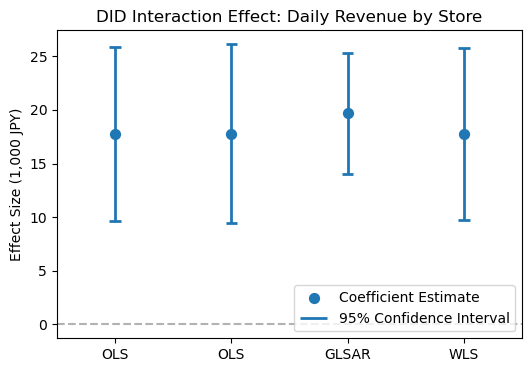

Bars crossing zero indicate no statistically significant difference.
95%信頼区間が0をまたぐ場合、統計的に有意な差があるとはいえない


In [116]:
# coefficientと95%ciをグラフ化
groups = df_daily_results['group'].tolist()
x_pos = np.arange(len(groups))

plt.figure(figsize=(6, 4))
plt.scatter(x_pos, df_daily_results['coefficient'], color='tab:blue', s=50, zorder=3, label='Coefficient Estimate')  # 点(coef)
plt.vlines(x_pos, df_daily_results['ci_lower'], df_daily_results['ci_upper'], colors='tab:blue', lw=2, label='95% Confidence Interval')  # 縦棒（ci）
plt.hlines(df_daily_results['ci_lower'], x_pos - 0.05, x_pos + 0.05, colors='tab:blue', lw=2)  # 棒の下の横線
plt.hlines(df_daily_results['ci_upper'], x_pos - 0.05, x_pos + 0.05, colors='tab:blue', lw=2)  # 棒の上の横線

plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlim(-0.5, len(groups) - 0.5)  # x軸の余白調整、未指定だとx軸の左右に余白がなくて見映えがよくない
plt.xticks(x_pos, groups)
# plt.xlabel('Group')
plt.ylabel('Effect Size (1,000 JPY)')
plt.title('DID Interaction Effect: Daily Revenue by Store')
plt.legend(loc='lower right')
# plt.tight_layout()
plt.show()

print("Bars crossing zero indicate no statistically significant difference.")
print("95%信頼区間が0をまたぐ場合、統計的に有意な差があるとはいえない")

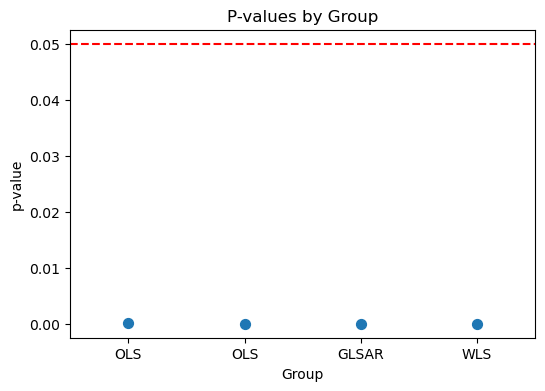

If the p-value is below 0.05, the result is considered statistically significant.
p値が0.05未満であれば、統計的に有意な結果とされる。
If the p-value is above 0.05, the result is not considered statistically significant.
p値が0.05以上であれば、統計的に有意な結果とはされない。


In [117]:
# p値をグラフ化
plt.figure(figsize=(6, 4))
plt.scatter(x_pos, df_daily_results['p_value'], color='tab:blue', s=50, zorder=3, label='P-Value')
plt.axhline(0.05, color='red', linestyle='--')
plt.xlim(-0.5, len(groups) - 0.5)  # x軸の余白調整、未指定だとx軸の左右に余白がなくて見栄えが良くない
plt.xlabel('Group')
plt.ylabel('p-value')
plt.xticks(x_pos, groups)
plt.title('P-values by Group')
# plt.legend(loc='best')
plt.show()   

print("If the p-value is below 0.05, the result is considered statistically significant.")
print("p値が0.05未満であれば、統計的に有意な結果とされる。")
print("If the p-value is above 0.05, the result is not considered statistically significant.")
print("p値が0.05以上であれば、統計的に有意な結果とはされない。")

In [118]:
# 格納してた値をdataframeにしてcopy
df_customer_results = pd.DataFrame(customer_results).copy()
# df_customer_results.round(3)
df_customer_results.style.format({
    'coefficient': '{:.1f}',    # 小数点第1位まで
    'p_value': '{:.6f}',        # 小数点第6位まで（0.000001が見えるように）
    'ci_lower': '{:.1f}',
    'ci_upper': '{:.1f}'
})

,group,note,coefficient,p_value,ci_lower,ci_upper
0,OLS,HC3,105.4,0.019110,17.2,193.5
1,FE OLS,HC3,136.5,0.009174,33.8,239.1
2,FE WLS,"HC3, weight=item_count",155.4,0.012637,33.3,277.5
3,FE WLS,"HC3, weight=unit_price",147.1,0.011808,32.6,261.6
4,FE OLS cluster,cluster=customer_id,136.5,0.008679,34.6,238.4
5,FE WLS cluster,"weight=item_count, cluster=customer_id",155.4,0.012328,33.7,277.1
6,FE WLS cluster,"weight=unit_price, cluster=customer_id",147.1,0.011149,33.5,260.7


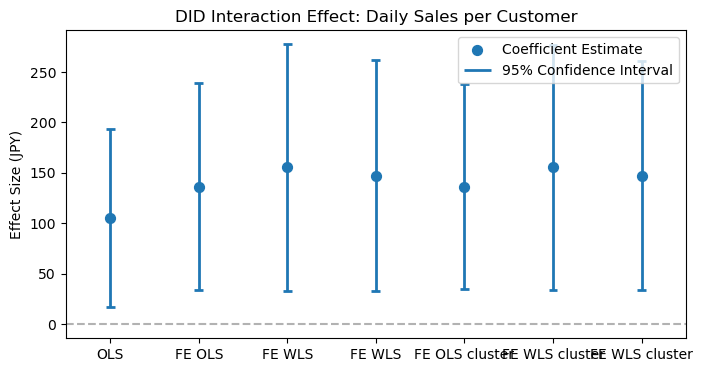

Bars crossing zero indicate no statistically significant difference.
95%信頼区間が0をまたぐ場合、統計的に有意な差があるとはいえない


In [119]:
# coefficientと95%ciをグラフ化
groups = df_customer_results['group'].tolist()
x_pos = np.arange(len(groups))

plt.figure(figsize=(8, 4))
plt.scatter(x_pos, df_customer_results['coefficient'], color='tab:blue', s=50, zorder=3, label='Coefficient Estimate')  # 点(coef)
plt.vlines(x_pos, df_customer_results['ci_lower'], df_customer_results['ci_upper'], colors='tab:blue', lw=2, label='95% Confidence Interval')  # 縦棒（ci）
plt.hlines(df_customer_results['ci_lower'], x_pos - 0.05, x_pos + 0.05, colors='tab:blue', lw=2)  # 棒の下の横線
plt.hlines(df_customer_results['ci_upper'], x_pos - 0.05, x_pos + 0.05, colors='tab:blue', lw=2)  # 棒の上の横線

plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlim(-0.5, len(groups) - 0.5)  # x軸の余白調整、未指定だとx軸の左右に余白がなくて見映えがよくない
plt.xticks(x_pos, groups)
# plt.xlabel('Group')
plt.ylabel('Effect Size (JPY)')
plt.title('DID Interaction Effect: Daily Sales per Customer')
plt.legend(loc='best')
# plt.tight_layout()
plt.show()

print("Bars crossing zero indicate no statistically significant difference.")
print("95%信頼区間が0をまたぐ場合、統計的に有意な差があるとはいえない")

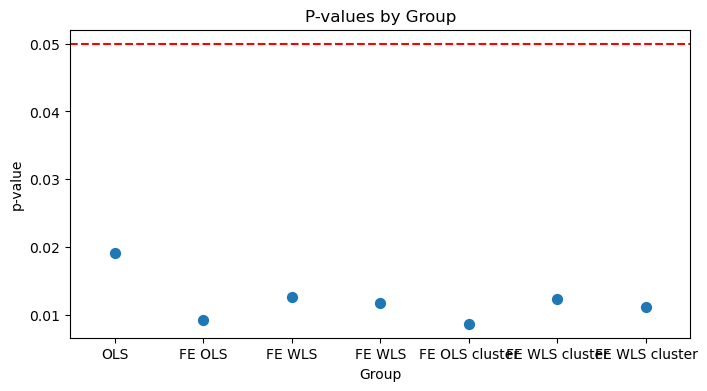

If the p-value is below 0.05, the result is considered statistically significant.
p値が0.05未満であれば、統計的に有意な結果とされる。
If the p-value is above 0.05, the result is not considered statistically significant.
p値が0.05以上であれば、統計的に有意な結果とはされない。


In [120]:
# p値をグラフ化
plt.figure(figsize=(8, 4))
plt.scatter(x_pos, df_customer_results['p_value'], color='tab:blue', s=50, zorder=3, label='P-Value')
plt.axhline(0.05, color='red', linestyle='--')
plt.xlim(-0.5, len(groups) - 0.5)  # x軸の余白調整、未指定だとx軸の左右に余白がなくて見栄えが良くない
plt.xlabel('Group')
plt.ylabel('p-value')
plt.xticks(x_pos, groups)
plt.title('P-values by Group')
# plt.legend(loc='best')
plt.show()   

print("If the p-value is below 0.05, the result is considered statistically significant.")
print("p値が0.05未満であれば、統計的に有意な結果とされる。")
print("If the p-value is above 0.05, the result is not considered statistically significant.")
print("p値が0.05以上であれば、統計的に有意な結果とはされない。")

# 各モデルの前提と拡張の整理

| モデル | 考慮した要素（緩めた前提） | 残っている暗黙の前提 |
| :--- | :--- | :--- |
| **OLS** | なし | 等分散、残差の独立性、**個体差なし** |
| **FE-OLS** | **個体差**（User固定効果） | 等分散、残差の独立性 |
| **FE-WLS** | 個体差 ＋ **不均一分散**（重み付け） | 残差の独立性 |
| **FE-WLS + Cluster** | 個体差 ＋ 不均一分散 ＋ **ユーザー内相関** | **ユーザー間は独立** |

# モデルごとの仮定の違い
- OLS
  - 個体差は平均化され問題にならないと仮定
  - 残差は等分散かつ独立
- FE(OLS)
  - customer_idごとの不変の個体差をコントロール
  - ただし残差は等分散かつ独立と仮定
- FE(WLS)
  - 個体差をコントロール
  - 観測精度の違い（hogeの大小）を考慮
  - ただし残差は独立と仮定（モデルで説明しきれなかった同一customer_id内の異なる時点の残差）
- FE(WLS + cluster)
  - 個体差をコントロール
  - 観測精度の違いを考慮
  - 同一customer_id内の残差自己相関を許容
  - 独立な単位はcustomer_id